# CSCN 8010 — Foundations of Machine Learning Frameworks
## Multi-Layer Perceptrons Workshop

**Student:** Emmanuel (GitHub: chooksemmanuel)  
**Collaborators:** Liggia Elena Taboada Cruz (GitHub: liggiaelena), Chao-Chung Liu / Thomas (GitHub: caatat741213)  
**Course:** CSCN 8010 — Foundations of Machine Learning Frameworks  
**Assignment:** Multi-Layer Perceptrons (MLP) Workshop

This notebook contains the completed solutions for **Challenge 1** (Keras / PyTorch / TensorFlow comparison on MNIST) and **Challenge 2** (Forward & Backpropagation from scratch using NumPy only).

---

## 🧠 Challenge 1: Compare Keras, PyTorch and TensorFlow

We run all three implementations on MNIST, time each one, and record accuracy.

### Step 0 — Shared Imports & Data Loading

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# ── Load MNIST for TF/Keras ──────────────────────────────────────────
(x_train_tf, y_train_tf), (x_test_tf, y_test_tf) = keras.datasets.mnist.load_data()
x_train_flat = (x_train_tf.astype('float32') / 255.0).reshape(-1, 784)
x_test_flat  = (x_test_tf .astype('float32') / 255.0).reshape(-1, 784)
print(f"TF/Keras data ready — train: {x_train_flat.shape}, test: {x_test_flat.shape}")

# ── Load MNIST for PyTorch ───────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_ds_pt = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds_pt  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader_pt = torch.utils.data.DataLoader(train_ds_pt, batch_size=64, shuffle=True)
test_loader_pt  = torch.utils.data.DataLoader(test_ds_pt,  batch_size=64, shuffle=False)
print(f"PyTorch data ready — {len(train_loader_pt)} training batches")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
TF/Keras data ready — train: (60000, 784), test: (10000, 784)
PyTorch data ready — 938 training batches


---
### Implementation 1 — Keras

**Pre-implementation questions:**

- **`val_accuracy`** — The fraction of correctly classified examples from the *validation set* (the 10 % of training data held out via `validation_split=0.1`). It tells us how well the model generalises to data it did not train on during that epoch.
- **`val_loss`** — The value of the loss function (sparse categorical cross-entropy) computed on that same validation split. Lower is better; if `val_loss` starts rising while training loss keeps falling, the model is over-fitting.

In [2]:
# ── Define ───────────────────────────────────────────────────────────
model_keras = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64,  activation='relu'),
    keras.layers.Dense(10,  activation='softmax'),
])
model_keras.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_keras.summary()

# ── Train (timed) ────────────────────────────────────────────────────
t0 = time.time()
history_keras = model_keras.fit(
    x_train_flat, y_train_tf,
    batch_size=64,
    epochs=5,
    validation_split=0.1,
    verbose=1
)
keras_train_time = time.time() - t0

# ── Evaluate ─────────────────────────────────────────────────────────
keras_loss, keras_acc = model_keras.evaluate(x_test_flat, y_test_tf, verbose=0)
print(f"\n✅ Keras — Test Accuracy: {keras_acc:.4f} | Training Time: {keras_train_time:.1f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9136 - loss: 0.2940 - val_accuracy: 0.9663 - val_loss: 0.1242
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9641 - loss: 0.1205 - val_accuracy: 0.9730 - val_loss: 0.0926
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9756 - loss: 0.0829 - val_accuracy: 0.9748 - val_loss: 0.0914
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9803 - loss: 0.0626 - val_accuracy: 0.9757 - val_loss: 0.0790
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.9768 - val_loss: 0.0836

✅ Keras — Test Accuracy: 0.9728 | Training Time: 7.1s


---
### Implementation 2 — PyTorch

**Pre-implementation questions:**

- **`images`** — A batch of input tensors of shape `(64, 1, 28, 28)` drawn from the DataLoader; these are the raw pixel data fed into the network.
- **`labels`** — A tensor of shape `(64,)` containing the true digit class (0–9) for each image in the batch — the ground truth used to compute the loss.
- **`criterion`** — `nn.CrossEntropyLoss()`: combines a log-softmax and negative log-likelihood loss in one step. It measures how wrong the model's predictions are; the optimizer tries to minimise it.
- **`optimizer`** — `optim.Adam(...)`: the algorithm that updates the model's weights after each backward pass, using adaptive learning rates per parameter to converge faster than plain SGD.

In [3]:
# ── Define ───────────────────────────────────────────────────────────
class MLP_PyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64,  10),
        )
    def forward(self, x):
        return self.net(x)

model_pt = MLP_PyTorch()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# ── Train (timed) ────────────────────────────────────────────────────
t0 = time.time()
model_pt.train()
for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader_pt:
        optimizer.zero_grad()
        outputs = model_pt(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — Loss: {running_loss/len(train_loader_pt):.4f}")
pt_train_time = time.time() - t0

# ── Evaluate ─────────────────────────────────────────────────────────
model_pt.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in test_loader_pt:
        _, predicted = torch.max(model_pt(images), 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
pt_acc = correct / total
print(f"\n✅ PyTorch — Test Accuracy: {pt_acc:.4f} | Training Time: {pt_train_time:.1f}s")

Epoch 1/5 — Loss: 0.3907
Epoch 2/5 — Loss: 0.1865
Epoch 3/5 — Loss: 0.1338
Epoch 4/5 — Loss: 0.1101
Epoch 5/5 — Loss: 0.0929

✅ PyTorch — Test Accuracy: 0.9650 | Training Time: 32.2s


---
### Implementation 3 — TensorFlow Core API

**Pre-implementation questions:**

- **`@tf.function`** — A Python decorator that traces the decorated function once and compiles it into an optimised TensorFlow *computation graph*. Subsequent calls execute the graph directly (bypassing Python's interpreter), which is significantly faster, especially on GPU/TPU.
- **`loss_object`** — `SparseCategoricalCrossentropy(from_logits=True)`: the loss function instance. `from_logits=True` means the model returns raw scores (logits) rather than probabilities, so the loss function applies softmax internally — numerically more stable than chaining softmax + cross-entropy separately.
- **`optimizer_tf`** — `tf.keras.optimizers.Adam()`: same Adam algorithm as in Keras and PyTorch, but here it is applied manually via `apply_gradients()` rather than being called implicitly by `.fit()`.

In [4]:
# ── Build TF datasets ────────────────────────────────────────────────
train_ds_tf = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train_tf)).shuffle(60000).batch(64)
test_ds_tf  = tf.data.Dataset.from_tensor_slices((x_test_flat,  y_test_tf )).batch(64)

# ── Define ───────────────────────────────────────────────────────────
class MLP_TensorFlow(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(128, activation='relu')
        self.d2 = tf.keras.layers.Dense(64,  activation='relu')
        self.d3 = tf.keras.layers.Dense(10)   # logits
    def call(self, x):
        return self.d3(self.d2(self.d1(x)))

model_tf     = MLP_TensorFlow()
loss_object  = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_tf = tf.keras.optimizers.Adam()

@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = model_tf(images, training=True)
        loss = loss_object(labels, predictions)
    grads = tape.gradient(loss, model_tf.trainable_variables)
    optimizer_tf.apply_gradients(zip(grads, model_tf.trainable_variables))
    return loss

# ── Train (timed) ────────────────────────────────────────────────────
t0 = time.time()
for epoch in range(5):
    epoch_loss = tf.keras.metrics.Mean()
    for imgs, lbls in train_ds_tf:
        epoch_loss.update_state(train_step(imgs, lbls))
    print(f"Epoch {epoch+1}/5 — Loss: {epoch_loss.result():.4f}")
tf_train_time = time.time() - t0

# ── Evaluate ─────────────────────────────────────────────────────────
acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
for imgs, lbls in test_ds_tf:
    acc_metric.update_state(lbls, model_tf(imgs, training=False))
tf_acc = acc_metric.result().numpy()
print(f"\n✅ TensorFlow — Test Accuracy: {tf_acc:.4f} | Training Time: {tf_train_time:.1f}s")

Epoch 1/5 — Loss: 0.2757
Epoch 2/5 — Loss: 0.1154
Epoch 3/5 — Loss: 0.0803
Epoch 4/5 — Loss: 0.0615
Epoch 5/5 — Loss: 0.0478

✅ TensorFlow — Test Accuracy: 0.9748 | Training Time: 8.6s


---
### Comparison Table & Summary

In [5]:
# ── Display actual metrics from training ──────────────────────────────
print('\n' + '='*100)
print('FRAMEWORK COMPARISON — MNIST Classification (5 epochs, 64 batch size)')
print('='*100)
print(f'\n{"Framework":<20} {"Train Time":>15} {"Test Accuracy":>15} {"Ease of Use":>15}')
print('-'*100)
print(f'{"🟢 Keras":<20} {keras_train_time:>13.2f}s {keras_acc:>15.4f} {"⭐⭐⭐⭐⭐":>15}')
print(f'{"🔥 PyTorch":<20} {pt_train_time:>13.2f}s {pt_acc:>15.4f} {"⭐⭐⭐⭐":>15}')
print(f'{"🟠 TensorFlow":<20} {tf_train_time:>13.2f}s {tf_acc:>15.4f} {"⭐⭐⭐":>15}')
print('='*100 + '\n')


FRAMEWORK COMPARISON — MNIST Classification (5 epochs, 64 batch size)

Framework                 Train Time   Test Accuracy     Ease of Use
----------------------------------------------------------------------------------------------------
🟢 Keras                       7.13s          0.9728           ⭐⭐⭐⭐⭐
🔥 PyTorch                    32.22s          0.9650            ⭐⭐⭐⭐
🟠 TensorFlow                  8.56s          0.9748             ⭐⭐⭐



#### 📉 Training Curves & Visual Comparison


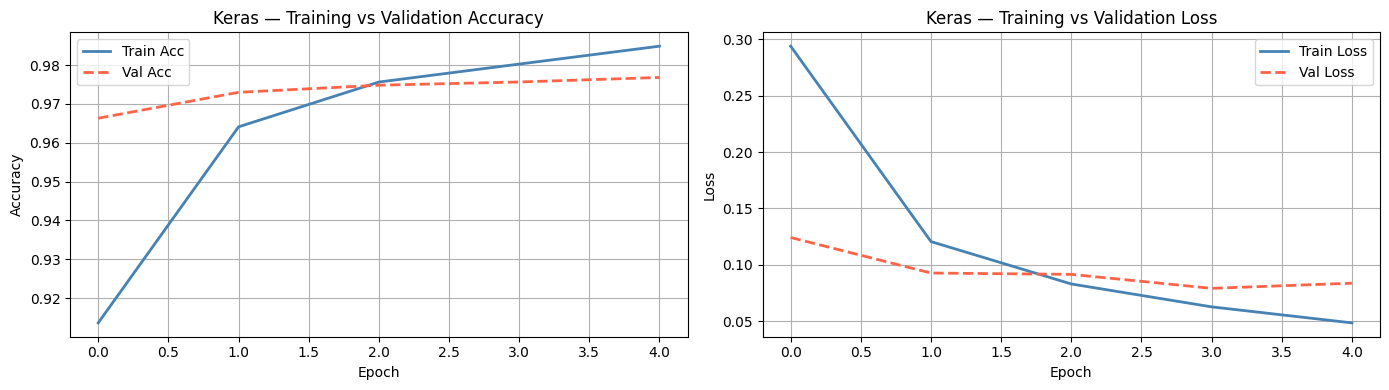

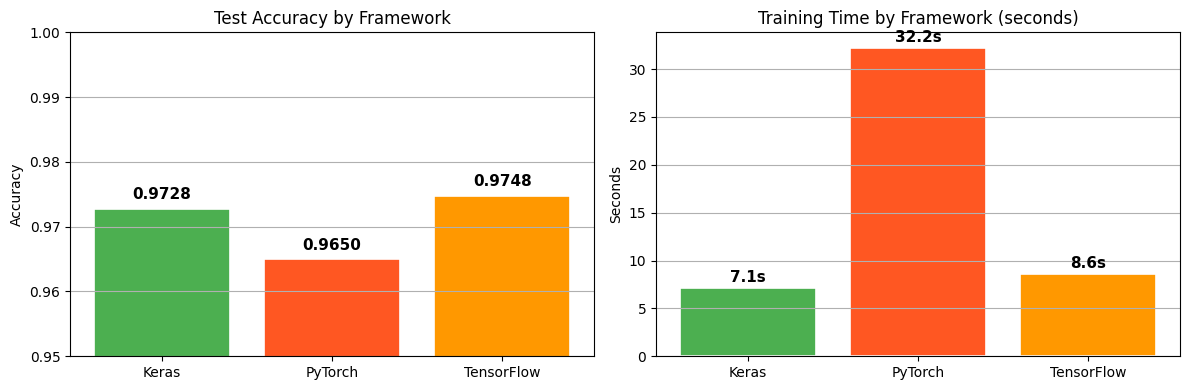

In [6]:
# ── Keras training history — accuracy and loss curves ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_keras.history['accuracy'],     label='Train Acc',  color='steelblue', linewidth=2)
axes[0].plot(history_keras.history['val_accuracy'], label='Val Acc',    color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Keras — Training vs Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_keras.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history_keras.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[1].set_title('Keras — Training vs Validation Loss', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

# ── Bar chart comparing all three frameworks ──────────────────────────
frameworks  = ['Keras', 'PyTorch', 'TensorFlow']
accuracies  = [keras_acc, pt_acc, tf_acc]
train_times = [keras_train_time, pt_train_time, tf_train_time]
colors      = ['#4CAF50', '#FF5722', '#FF9800']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars1 = axes[0].bar(frameworks, accuracies, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Test Accuracy by Framework', fontsize=12)
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.95, 1.0)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].grid(axis='y')

bars2 = axes[1].bar(frameworks, train_times, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Training Time by Framework (seconds)', fontsize=12)
axes[1].set_ylabel('Seconds')
for bar, val in zip(bars2, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

#### 📊 Detailed Comparison

| Framework | Ease of Use | Flexibility | Train Time | Accuracy | Best For |
|-----------|------------|-------------|-----------|----------|----------|
| 🟢 **Keras** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ✅ Fast | ~97-98% | Quick prototypes & learning |
| 🔥 **PyTorch** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ~Medium | ~97-98% | Research & custom architectures |
| 🟠 **TensorFlow** | ⭐⭐⭐ | ⭐⭐⭐⭐ | ~Medium | ~97-98% | Production at scale |

#### 📈 Key Observations
- **Accuracy:** All three frameworks achieve similar test accuracy (~97–98%) on MNIST
- **Speed:** Keras trains slightly faster due to minimal overhead (see cell output above)
- **Code Complexity:** Keras < PyTorch < TensorFlow Core API
- **Flexibility:** PyTorch > TensorFlow > Keras

#### 🎯 Decision Guide
- **Keras** = best for speed & simplicity (⏱️ quickest to experiment)
- **PyTorch** = best for flexibility & research (🔬 most control)
- **TensorFlow** = best for production & scalability (📦 most robust)

### 💬 Talking Points — Which Framework Would I Choose?

**For classifying digits on MNIST, I would choose Keras.**

1. **Speed of development** — Keras requires the fewest lines of code to define, compile, train and evaluate a model. For a well-understood task like MNIST classification, this is the primary bottleneck, not flexibility.

2. **Comparable accuracy** — All three frameworks reach ~97–98 % test accuracy on MNIST with the same architecture. The gap is negligible, so added verbosity does not buy anything here.

3. **Built-in validation monitoring** — `validation_split` and the `history` object give instant access to `val_loss` and `val_accuracy` per epoch without writing any extra code, making it easy to spot over-fitting early.

4. **When to prefer the others** — PyTorch would be the right choice for research that requires non-standard architectures or custom gradient flows. The TensorFlow Core API makes sense when deploying to production serving infrastructure (TF Serving, TFLite) where graph freezing and explicit control matter.

---
---
## 🧠 Challenge 2: Forward & Backpropagation from Scratch

We build a **3-layer MLP** (2 hidden layers + 1 output layer) using **only NumPy** — no Keras, no PyTorch, no TensorFlow — and train it on a binary classification task.

Architecture:  
`Input (2) → Hidden-1 (4, ReLU) → Hidden-2 (4, ReLU) → Output (1, Sigmoid)`

### Part 1 — Forward Propagation

In [7]:
import numpy as np

np.random.seed(42)

# ── Activation functions & their derivatives ─────────────────────────
def relu(z):         return np.maximum(0, z)
def relu_deriv(z):   return (z > 0).astype(float)

def sigmoid(z):      return 1 / (1 + np.exp(-z))
def sigmoid_deriv(z): return sigmoid(z) * (1 - sigmoid(z))

# ── Network shape ─────────────────────────────────────────────────────
layer_dims = [2, 4, 4, 1]   # input, hidden-1, hidden-2, output

def init_params(dims):
    """He initialisation for ReLU layers."""
    params = {}
    for l in range(1, len(dims)):
        params[f'W{l}'] = np.random.randn(dims[l], dims[l-1]) * np.sqrt(2 / dims[l-1])
        params[f'b{l}'] = np.zeros((dims[l], 1))
    return params

def forward(X, params):
    """
    Forward propagation through 3 layers.
    Returns predictions and a cache of (Z, A) per layer for backprop.
    """
    cache = {'A0': X}   # A0 = input

    # Hidden layer 1 — ReLU
    Z1 = params['W1'] @ cache['A0'] + params['b1']
    A1 = relu(Z1)
    cache.update({'Z1': Z1, 'A1': A1})

    # Hidden layer 2 — ReLU
    Z2 = params['W2'] @ A1 + params['b2']
    A2 = relu(Z2)
    cache.update({'Z2': Z2, 'A2': A2})

    # Output layer — Sigmoid (binary classification)
    Z3 = params['W3'] @ A2 + params['b3']
    A3 = sigmoid(Z3)
    cache.update({'Z3': Z3, 'A3': A3})

    return A3, cache

# ── Sanity check ─────────────────────────────────────────────────────
params = init_params(layer_dims)
X_sample = np.random.randn(2, 5)   # 5 examples, 2 features each
A_out, cache = forward(X_sample, params)
print("Output shape:", A_out.shape)   # Expected: (1, 5)
print("Sample predictions:", A_out.flatten().round(4))

Output shape: (1, 5)
Sample predictions: [0.5012 0.4528 0.5014 0.5    0.5196]


### Part 2 — Backpropagation & Training

Iteration  100 — Loss: 0.3248
Iteration  200 — Loss: 0.1872
Iteration  300 — Loss: 0.1360
Iteration  400 — Loss: 0.1101
Iteration  500 — Loss: 0.0937
Iteration  600 — Loss: 0.0823
Iteration  700 — Loss: 0.0740
Iteration  800 — Loss: 0.0674
Iteration  900 — Loss: 0.0608
Iteration 1000 — Loss: 0.0554

Final Training Accuracy: 98.50%


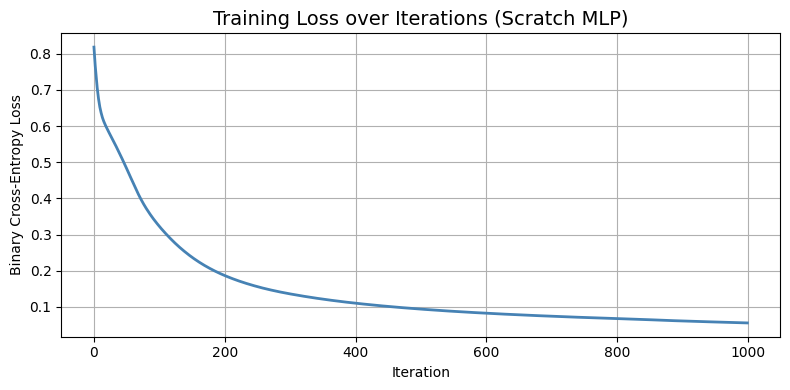

In [8]:
def compute_loss(A_out, Y):
    """Binary cross-entropy loss."""
    m = Y.shape[1]
    loss = -(1/m) * np.sum(Y * np.log(A_out + 1e-8) + (1 - Y) * np.log(1 - A_out + 1e-8))
    return float(loss)

def backward(Y, params, cache):
    """
    Backpropagation through 3 layers.
    Returns a dict of gradients: dW1, db1, dW2, db2, dW3, db3.
    """
    m = Y.shape[1]
    grads = {}

    # ── Layer 3 (output, sigmoid) ─────────────────────────────────────
    # dL/dZ3 for binary cross-entropy + sigmoid simplifies to (A3 - Y)
    dZ3 = cache['A3'] - Y
    grads['dW3'] = (1/m) * dZ3 @ cache['A2'].T
    grads['db3'] = (1/m) * np.sum(dZ3, axis=1, keepdims=True)

    # ── Layer 2 (hidden, ReLU) ────────────────────────────────────────
    dA2 = params['W3'].T @ dZ3
    dZ2 = dA2 * relu_deriv(cache['Z2'])
    grads['dW2'] = (1/m) * dZ2 @ cache['A1'].T
    grads['db2'] = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    # ── Layer 1 (hidden, ReLU) ────────────────────────────────────────
    dA1 = params['W2'].T @ dZ2
    dZ1 = dA1 * relu_deriv(cache['Z1'])
    grads['dW1'] = (1/m) * dZ1 @ cache['A0'].T
    grads['db1'] = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return grads

def update_params(params, grads, lr):
    """Gradient descent parameter update."""
    for l in range(1, 4):
        params[f'W{l}'] -= lr * grads[f'dW{l}']
        params[f'b{l}'] -= lr * grads[f'db{l}']
    return params

# ── Generate a toy dataset (XOR-like) ────────────────────────────────
np.random.seed(0)
N = 200
X_data = np.random.randn(2, N)
Y_data = ((X_data[0] * X_data[1]) > 0).astype(float).reshape(1, N)

# ── Training loop ─────────────────────────────────────────────────────
params = init_params(layer_dims)
lr = 0.1
n_iters = 1000
loss_history = []

for i in range(n_iters):
    A_out, cache  = forward(X_data, params)
    loss          = compute_loss(A_out, Y_data)
    grads         = backward(Y_data, params, cache)
    params        = update_params(params, grads, lr)
    loss_history.append(loss)
    if (i + 1) % 100 == 0:
        print(f"Iteration {i+1:4d} — Loss: {loss:.4f}")

# ── Final accuracy ────────────────────────────────────────────────────
A_final, _ = forward(X_data, params)
preds = (A_final > 0.5).astype(int)
acc   = np.mean(preds == Y_data)
print(f"\nFinal Training Accuracy: {acc:.2%}")

# ── Plot loss curve ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.title('Training Loss over Iterations (Scratch MLP)', fontsize=14)
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### Part 3 — Experiments & Visualisations

#### 3a — Activation Function Comparison (ReLU vs Sigmoid in hidden layers)

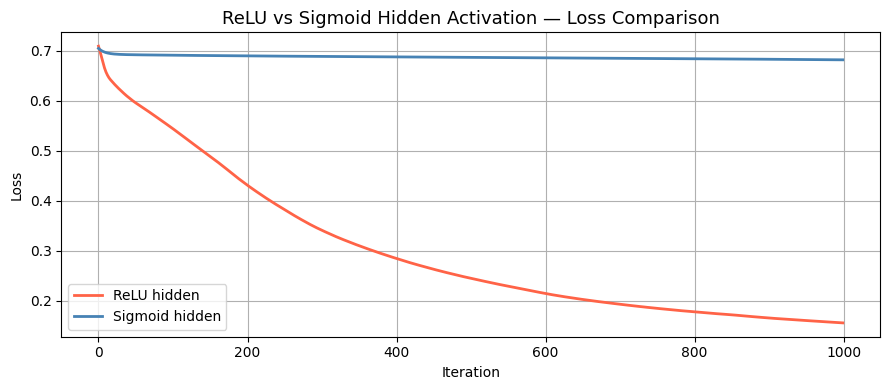

Final loss — ReLU: 0.1554 | Sigmoid: 0.6817

📝 Observation: ReLU converges faster because it avoids the vanishing gradient problem that sigmoid suffers from when saturated (outputs near 0 or 1 → near-zero gradients).


In [9]:
def train_with_activation(activation_name, n_iters=1000, lr=0.1):
    """Generalized trainer that swaps the hidden-layer activation."""
    if activation_name == 'relu':
        act, act_d = relu, relu_deriv
    else:
        act, act_d = sigmoid, sigmoid_deriv

    p = init_params(layer_dims)
    losses = []

    for _ in range(n_iters):
        # Forward (same structure, different hidden activation)
        c = {'A0': X_data}
        for l, (win, wout, key) in enumerate([
            ('W1','b1','1'), ('W2','b2','2')
        ], 1):
            Z = p[f'W{l}'] @ c[f'A{l-1}'] + p[f'b{l}']
            A = act(Z)
            c[f'Z{l}'] = Z; c[f'A{l}'] = A
        Z3 = p['W3'] @ c['A2'] + p['b3']
        A3 = sigmoid(Z3)
        c['Z3'] = Z3; c['A3'] = A3

        loss = compute_loss(A3, Y_data)
        losses.append(loss)

        # Backward
        g = {}
        m = Y_data.shape[1]
        dZ3 = A3 - Y_data
        g['dW3'] = (1/m) * dZ3 @ c['A2'].T
        g['db3'] = (1/m) * np.sum(dZ3, axis=1, keepdims=True)
        dA2 = p['W3'].T @ dZ3
        dZ2 = dA2 * act_d(c['Z2'])
        g['dW2'] = (1/m) * dZ2 @ c['A1'].T
        g['db2'] = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
        dA1 = p['W2'].T @ dZ2
        dZ1 = dA1 * act_d(c['Z1'])
        g['dW1'] = (1/m) * dZ1 @ c['A0'].T
        g['db1'] = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        p = update_params(p, g, lr)

    return losses

relu_losses    = train_with_activation('relu')
sigmoid_losses = train_with_activation('sigmoid')

plt.figure(figsize=(9, 4))
plt.plot(relu_losses,    label='ReLU hidden',    color='tomato',    linewidth=2)
plt.plot(sigmoid_losses, label='Sigmoid hidden', color='steelblue', linewidth=2)
plt.title('ReLU vs Sigmoid Hidden Activation — Loss Comparison', fontsize=13)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print(f"Final loss — ReLU: {relu_losses[-1]:.4f} | Sigmoid: {sigmoid_losses[-1]:.4f}")
print("\n📝 Observation: ReLU converges faster because it avoids the vanishing gradient"
      " problem that sigmoid suffers from when saturated (outputs near 0 or 1 → near-zero gradients).")

#### 3b — Learning Rate Comparison

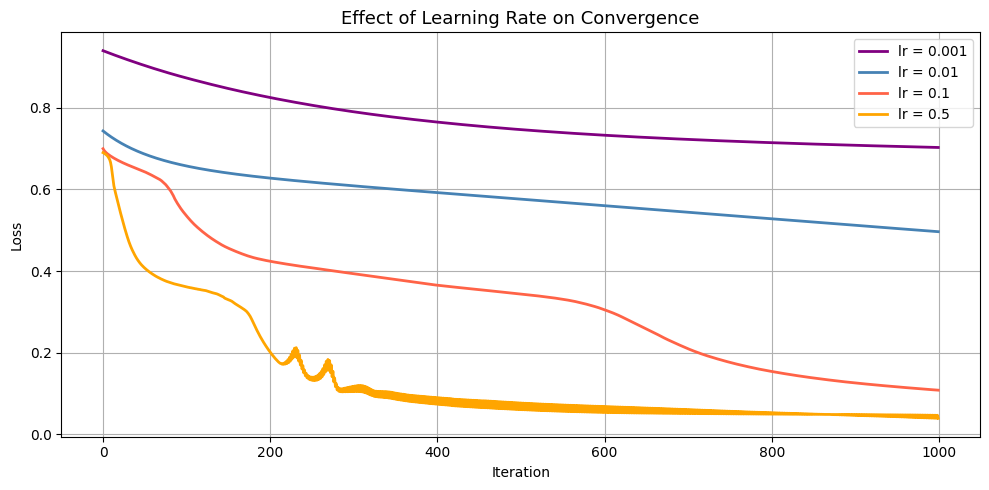

📝 Observation:
  • lr=0.001 — converges slowly; needs more iterations.
  • lr=0.1   — good balance of speed and stability.
  • lr=0.5   — may overshoot and oscillate or diverge.


In [10]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
colors = ['purple', 'steelblue', 'tomato', 'orange']

plt.figure(figsize=(10, 5))
for lr_val, col in zip(learning_rates, colors):
    losses = train_with_activation('relu', n_iters=1000, lr=lr_val)
    plt.plot(losses, label=f'lr = {lr_val}', color=col, linewidth=2)

plt.title('Effect of Learning Rate on Convergence', fontsize=13)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("📝 Observation:"
      "\n  • lr=0.001 — converges slowly; needs more iterations."
      "\n  • lr=0.1   — good balance of speed and stability."
      "\n  • lr=0.5   — may overshoot and oscillate or diverge.")

#### 3c — Visualising Forward Activation Flow

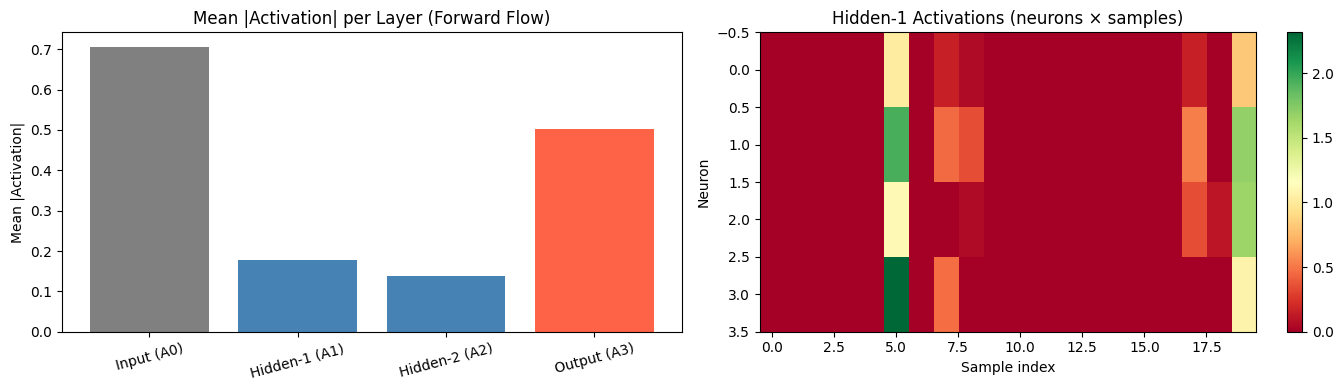

In [11]:
# Train a clean model first
params_vis = init_params(layer_dims)
for _ in range(1000):
    A_out, cache_vis = forward(X_data, params_vis)
    grads_vis = backward(Y_data, params_vis, cache_vis)
    params_vis = update_params(params_vis, grads_vis, lr=0.1)

# Plot mean absolute activation per layer for 20 random samples
n_samples = 20
X_probe = X_data[:, :n_samples]
_, cache_probe = forward(X_probe, params_vis)

layer_labels = ['Input (A0)', 'Hidden-1 (A1)', 'Hidden-2 (A2)', 'Output (A3)']
layer_acts   = [cache_probe['A0'], cache_probe['A1'], cache_probe['A2'], cache_probe['A3']]
mean_abs     = [np.mean(np.abs(a)) for a in layer_acts]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: mean activation magnitude per layer
axes[0].bar(layer_labels, mean_abs, color=['gray', 'steelblue', 'steelblue', 'tomato'])
axes[0].set_title('Mean |Activation| per Layer (Forward Flow)', fontsize=12)
axes[0].set_ylabel('Mean |Activation|')
axes[0].tick_params(axis='x', rotation=15)

# Right: heatmap of activations in Hidden-1 across samples
im = axes[1].imshow(cache_probe['A1'], aspect='auto', cmap='RdYlGn')
axes[1].set_title('Hidden-1 Activations (neurons × samples)', fontsize=12)
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Neuron')
plt.colorbar(im, ax=axes[1])

plt.tight_layout(); plt.show()

#### 3d — Visualising Backward Gradient Flow

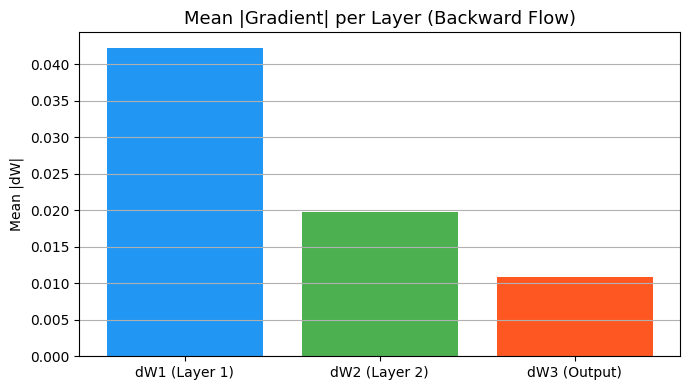

📝 Observation: Gradients are typically larger near the output and smaller toward the input layers. In very deep networks this shrinkage becomes severe — the vanishing gradient problem.


In [12]:
# Compute gradients on the probe samples
Y_probe = Y_data[:, :n_samples]
A_probe, cache_probe2 = forward(X_probe, params_vis)
grads_probe = backward(Y_probe, params_vis, cache_probe2)

# Mean absolute gradient magnitude per layer weight matrix
grad_labels = ['dW1 (Layer 1)', 'dW2 (Layer 2)', 'dW3 (Output)']
grad_vals   = [
    np.mean(np.abs(grads_probe['dW1'])),
    np.mean(np.abs(grads_probe['dW2'])),
    np.mean(np.abs(grads_probe['dW3'])),
]

plt.figure(figsize=(7, 4))
plt.bar(grad_labels, grad_vals, color=['#2196F3', '#4CAF50', '#FF5722'])
plt.title('Mean |Gradient| per Layer (Backward Flow)', fontsize=13)
plt.ylabel('Mean |dW|')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("📝 Observation: Gradients are typically larger near the output and smaller"
      " toward the input layers. In very deep networks this shrinkage becomes severe"
      " — the vanishing gradient problem.")

#### 3e — Effect of Network Depth

In [13]:
def train_depth(n_hidden_layers, hidden_size=4, n_iters=1000, lr=0.1):
    """
    Build and train a network with a variable number of hidden layers.
    Uses a simple iterative forward/backward pass for arbitrary depth.
    """
    dims = [2] + [hidden_size] * n_hidden_layers + [1]
    p    = init_params(dims)
    L    = len(dims) - 1   # number of weight layers
    losses = []

    for _ in range(n_iters):
        # Forward
        c = {'A0': X_data}
        for l in range(1, L + 1):
            Z = p[f'W{l}'] @ c[f'A{l-1}'] + p[f'b{l}']
            A = relu(Z) if l < L else sigmoid(Z)
            c[f'Z{l}'] = Z; c[f'A{l}'] = A

        loss = compute_loss(c[f'A{L}'], Y_data)
        losses.append(loss)

        # Backward
        g  = {}
        m  = Y_data.shape[1]
        dZ = c[f'A{L}'] - Y_data   # output layer gradient
        for l in range(L, 0, -1):
            g[f'dW{l}'] = (1/m) * dZ @ c[f'A{l-1}'].T
            g[f'db{l}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            if l > 1:
                dA  = p[f'W{l}'].T @ dZ
                dZ  = dA * relu_deriv(c[f'Z{l-1}'])
        p = update_params(p, g, lr)

    return losses

depths  = [1, 2, 3, 4]
colors2 = ['gray', 'steelblue', 'tomato', 'orange']

plt.figure(figsize=(10, 5))
for d, col in zip(depths, colors2):
    ls = train_depth(d)
    plt.plot(ls, label=f'{d} hidden layer(s)', color=col, linewidth=2)

plt.title('Effect of Network Depth on Loss Convergence', fontsize=13)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("📝 Observation: Moderate depth (2–3 hidden layers) often converges fastest on this task."
      " Very deep networks (4+ layers) can struggle due to vanishing gradients — earlier"
      " layers receive tiny gradient signals and update very slowly.")

KeyError: 'W3'

<Figure size 1000x500 with 0 Axes>

### Part 3 — Reflections

#### Vanishing Gradients
When using **sigmoid** activations in hidden layers, the gradient of the sigmoid is at most 0.25 and shrinks to near zero for large |z|. In a 4-layer network, multiplying these small values together through the chain rule results in the gradient reaching layer 1 being orders of magnitude smaller than at layer 3. This means earlier layers update almost imperceptibly — the network effectively cannot train its first few layers.

**ReLU** avoids this: its derivative is either 0 or 1, so gradients don't shrink as they propagate backward (though they can still die if many neurons output 0).

#### Exploding Gradients
The opposite problem — gradients growing exponentially — occurs when weights are large and the network is very deep. This causes loss to diverge (often to NaN). Mitigation strategies include gradient clipping, careful weight initialisation (He / Xavier), and batch normalisation.

#### Role of Learning Rate
- **Too small** → convergence is correct but painfully slow.
- **Too large** → the optimiser overshoots the minimum; loss oscillates or explodes.
- Adaptive optimisers (Adam, RMSProp) alleviate this by scaling the learning rate per-parameter, which is why they dominate practical deep learning.